In [1]:
# Cell 1 — Test imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("All imports successful!")

TensorFlow version: 2.21.0
NumPy version: 2.4.6
All imports successful!


In [2]:
# Cell 2 — Check dataset structure
import os

DATASET_PATH = "../../ai_model/dataset"

categories = ["recyclable", "biodegradable", "residual", "special_waste", "none"]
splits = ["train", "validation", "test"]

print("Dataset structure check:")
print("=" * 40)

for split in splits:
    print(f"\n{split.upper()}:")
    for category in categories:
        path = os.path.join(DATASET_PATH, split, category)
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"  {category}: {count} images")
        else:
            print(f"  {category}: folder not found!")

Dataset structure check:

TRAIN:
  recyclable: 0 images
  biodegradable: 0 images
  residual: 0 images
  special_waste: 0 images
  none: 0 images

VALIDATION:
  recyclable: 0 images
  biodegradable: 0 images
  residual: 0 images
  special_waste: 0 images
  none: 0 images

TEST:
  recyclable: 0 images
  biodegradable: 0 images
  residual: 0 images
  special_waste: 0 images
  none: 0 images


In [1]:
# Cell 3 — Generate placeholder images for testing pipeline
import os
import numpy as np
from PIL import Image

DATASET_PATH = "../../ai_model/dataset"

categories = ["recyclable", "biodegradable", "residual", "special_waste", "none"]
splits = ["train", "validation", "test"]

# Different colors for each category so model can distinguish them
colors = {
    "recyclable": (0, 0, 255),      # Blue
    "biodegradable": (0, 255, 0),   # Green
    "residual": (128, 128, 128),    # Gray
    "special_waste": (255, 0, 0),   # Red
    "none": (255, 255, 255),        # White
}

# How many images per category per split
counts = {
    "train": 20,
    "validation": 5,
    "test": 5
}

print("Generating placeholder images...")
print("=" * 40)

for split in splits:
    for category in categories:
        path = os.path.join(DATASET_PATH, split, category)
        color = colors[category]
        num_images = counts[split]

        for i in range(num_images):
            # Create a 224x224 image with slight random noise
            img_array = np.full((224, 224, 3), color, dtype=np.uint8)
            noise = np.random.randint(-30, 30, (224, 224, 3))
            img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)

            img = Image.fromarray(img_array)
            img.save(os.path.join(path, f"{category}_{i}.jpg"))

        print(f"✓ {split}/{category}: {num_images} images generated")

print("\nDone! All placeholder images created.")

Generating placeholder images...
✓ train/recyclable: 20 images generated
✓ train/biodegradable: 20 images generated
✓ train/residual: 20 images generated
✓ train/special_waste: 20 images generated
✓ train/none: 20 images generated
✓ validation/recyclable: 5 images generated
✓ validation/biodegradable: 5 images generated
✓ validation/residual: 5 images generated
✓ validation/special_waste: 5 images generated
✓ validation/none: 5 images generated
✓ test/recyclable: 5 images generated
✓ test/biodegradable: 5 images generated
✓ test/residual: 5 images generated
✓ test/special_waste: 5 images generated
✓ test/none: 5 images generated

Done! All placeholder images created.


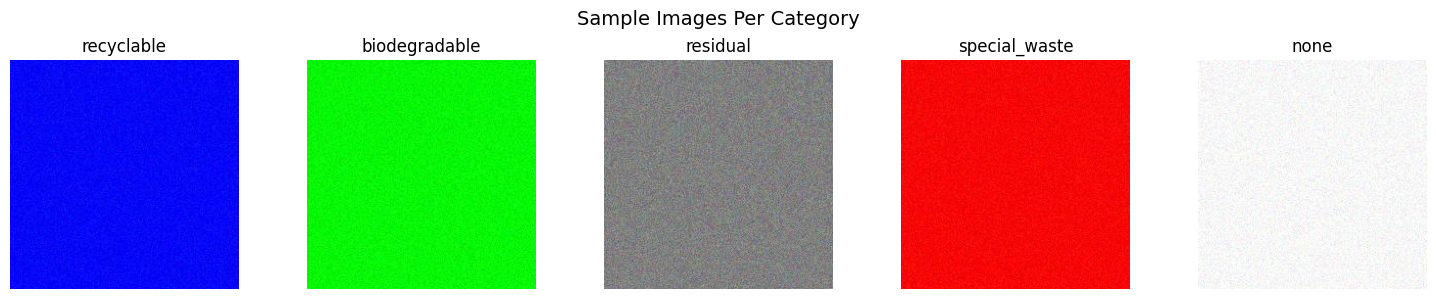

Preview complete!


In [2]:
# Cell 4 — Preview sample images from each category
import matplotlib.pyplot as plt
from PIL import Image
import os

DATASET_PATH = "../../ai_model/dataset"
categories = ["recyclable", "biodegradable", "residual", "special_waste", "none"]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Sample Images Per Category", fontsize=14)

for i, category in enumerate(categories):
    img_path = os.path.join(DATASET_PATH, "train", category, f"{category}_0.jpg")
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(category)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print("Preview complete!")

In [3]:
# Cell 5 — Load and prepare dataset
import tensorflow as tf

DATASET_PATH = "../../ai_model/dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

# Load training data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Load validation data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load test data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get class names
class_names = train_dataset.class_names
print("Categories found:", class_names)
print("Number of categories:", len(class_names))
print("\nDataset loaded successfully!")

Found 100 files belonging to 5 classes.
Found 25 files belonging to 5 classes.
Found 25 files belonging to 5 classes.
Categories found: ['biodegradable', 'none', 'recyclable', 'residual', 'special_waste']
Number of categories: 5

Dataset loaded successfully!


In [4]:
# Cell 6 — Build the AI model using MobileNet Transfer Learning
import tensorflow as tf

IMG_SIZE = (224, 224)
NUM_CLASSES = 5

# Load MobileNetV2 pre-trained on ImageNet
# include_top=False means we remove the last layer
# so we can add our own for waste classification
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model
# This means we don't retrain MobileNet's existing knowledge
# We only train our new layers on top
base_model.trainable = False

# Build our model on top of MobileNet
model = tf.keras.Sequential([
    # Data augmentation layer
    tf.keras.layers.Rescaling(1./255),
    
    # MobileNet base
    base_model,
    
    # Our custom classification layers
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
print("\nModel built successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)


Model built successfully!


In [5]:
# Cell 7 — Train the model
import tensorflow as tf

EPOCHS = 10

# Normalize pixel values for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Train the model
print("Starting training...")
print("=" * 40)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

print("\nTraining complete!")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.2%}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.2%}")

Starting training...
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - accuracy: 0.4600 - loss: 1.2681 - val_accuracy: 1.0000 - val_loss: 0.3558
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - accuracy: 0.8300 - loss: 0.4880 - val_accuracy: 1.0000 - val_loss: 0.1254
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.9800 - loss: 0.1767 - val_accuracy: 1.0000 - val_loss: 0.0563
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - accuracy: 0.9900 - loss: 0.0981 - val_accuracy: 1.0000 - val_loss: 0.0299
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - accuracy: 1.0000 - loss: 0.0785 - val_accuracy: 1.0000 - val_loss: 0.0185
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 250ms/step - accuracy: 0.9900 - loss: 0.0473 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - accuracy: 1.0000 - loss: 0.0362 - val_accuracy: 1.0000 - val_loss: 0.0110
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 1.0000 - loss: 0.02

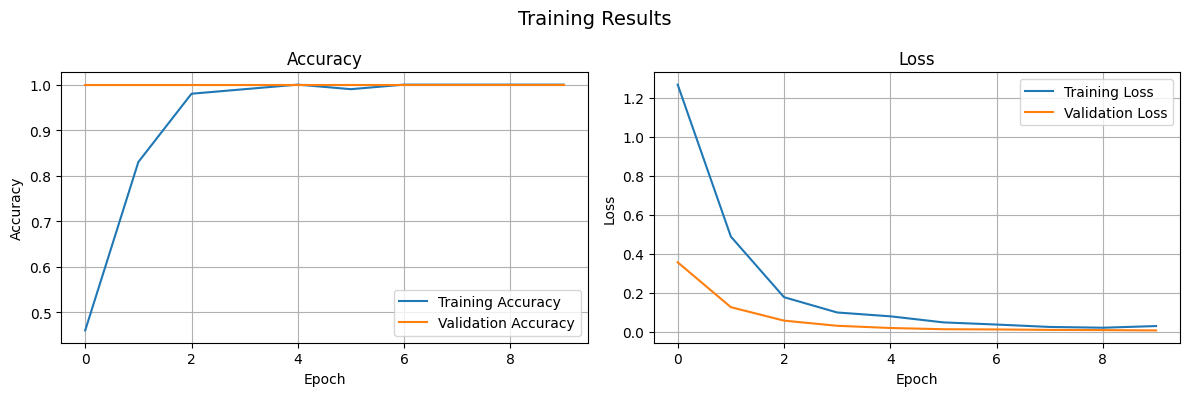

Training visualization complete!


In [6]:
# Cell 8 — Visualize training results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training Results", fontsize=14)

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
print("Training visualization complete!")

In [7]:
# Cell 9 — Evaluate model on test data
import numpy as np

print("Evaluating model on test data...")
print("=" * 40)

# Evaluate
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2%}")

# Predict on test data
print("\nSample predictions:")
print("-" * 40)

categories = ["biodegradable", "none", "recyclable", "residual", "special_waste"]

for images, labels in test_dataset.take(1):
    predictions = model.predict(images)
    for i in range(min(5, len(images))):
        predicted = categories[np.argmax(predictions[i])]
        actual = categories[labels[i].numpy()]
        confidence = np.max(predictions[i]) * 100
        status = "✓" if predicted == actual else "✗"
        print(f"{status} Actual: {actual:15} Predicted: {predicted:15} Confidence: {confidence:.1f}%")

Evaluating model on test data...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 1.0000 - loss: 0.0060

Test Loss: 0.0060
Test Accuracy: 100.00%

Sample predictions:
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
✓ Actual: biodegradable   Predicted: biodegradable   Confidence: 99.2%
✓ Actual: biodegradable   Predicted: biodegradable   Confidence: 99.6%
✓ Actual: biodegradable   Predicted: biodegradable   Confidence: 98.7%
✓ Actual: biodegradable   Predicted: biodegradable   Confidence: 99.4%
✓ Actual: biodegradable   Predicted: biodegradable   Confidence: 99.2%


In [8]:
# Cell 10 — Save the trained model
import os

SAVE_PATH = "../../ai_model/saved_model/waste_classifier.h5"

print("Saving model...")
model.save(SAVE_PATH)
print(f"✓ Model saved to: {SAVE_PATH}")

# Verify it was saved
if os.path.exists(SAVE_PATH):
    size = os.path.getsize(SAVE_PATH) / (1024 * 1024)
    print(f"✓ File size: {size:.2f} MB")
    print("\nModel saved successfully!")
else:
    print("✗ Something went wrong — file not found")

Saving model...
✓ Model saved to: ../../ai_model/saved_model/waste_classifier.h5
✓ File size: 10.86 MB

Model saved successfully!


In [9]:
# Cell 11 — Save in recommended Keras format
import os

SAVE_PATH_KERAS = "../../ai_model/saved_model/waste_classifier.keras"

print("Saving model in Keras format...")
model.save(SAVE_PATH_KERAS)
print(f"✓ Model saved to: {SAVE_PATH_KERAS}")

# Verify it was saved
if os.path.exists(SAVE_PATH_KERAS):
    size = os.path.getsize(SAVE_PATH_KERAS) / (1024 * 1024)
    print(f"✓ File size: {size:.2f} MB")
    print("\nModel saved successfully in Keras format!")
else:
    print("✗ Something went wrong — file not found")

Saving model in Keras format...
✓ Model saved to: ../../ai_model/saved_model/waste_classifier.keras
✓ File size: 11.07 MB

Model saved successfully in Keras format!


In [10]:
# Cell 12 — Test loading saved model and classifying an image
import tensorflow as tf
import numpy as np
from PIL import Image
import os

# Load the saved model
print("Loading saved model...")
loaded_model = tf.keras.models.load_model(
    "../../ai_model/saved_model/waste_classifier.keras"
)
print("✓ Model loaded successfully!")

# Define categories
CATEGORIES = ["biodegradable", "none", "recyclable", "residual", "special_waste"]

def classify_waste(image_path):
    """
    Takes an image path and returns waste classification
    This is the function Django will call
    """
    # Open and resize image
    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))
    
    # Convert to array and add batch dimension
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    predictions = loaded_model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])
    confidence = float(np.max(predictions[0]))
    
    return {
        "waste_type": CATEGORIES[predicted_index],
        "confidence": round(confidence * 100, 2)
    }

# Test with a sample image
test_image_path = "../../ai_model/dataset/test/recyclable/recyclable_0.jpg"
result = classify_waste(test_image_path)

print(f"\nTest Classification:")
print(f"  Image: recyclable_0.jpg")
print(f"  Predicted: {result['waste_type']}")
print(f"  Confidence: {result['confidence']}%")

Loading saved model...


c:\Users\admin\Desktop\AGOS_PROJECT\backend\venv\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✓ Model loaded successfully!

Test Classification:
  Image: recyclable_0.jpg
  Predicted: recyclable
  Confidence: 99.59%


In [11]:
# Cell 13 — Create the classifier.py file for Django integration
classifier_code = '''import tensorflow as tf
import numpy as np
from PIL import Image
import os

# Path to saved model
MODEL_PATH = os.path.join(os.path.dirname(__file__), "saved_model", "waste_classifier.keras")

# Waste categories — must match training order
CATEGORIES = ["biodegradable", "none", "recyclable", "residual", "special_waste"]

# Load model once when the module is imported
print("Loading AGOS waste classification model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")

def classify_waste(image_path: str) -> dict:
    """
    Classifies waste type from an image.
    
    Args:
        image_path: Path to the image file
        
    Returns:
        dict with waste_type and confidence
    """
    try:
        # Open and preprocess image
        img = Image.open(image_path).convert("RGB")
        img = img.resize((224, 224))
        
        # Convert to array and add batch dimension
        img_array = np.array(img)
        img_array = np.expand_dims(img_array, axis=0)
        
        # Predict
        predictions = model.predict(img_array, verbose=0)
        predicted_index = np.argmax(predictions[0])
        confidence = float(np.max(predictions[0]))
        
        return {
            "waste_type": CATEGORIES[predicted_index],
            "confidence": round(confidence * 100, 2),
            "success": True
        }
        
    except Exception as e:
        return {
            "waste_type": None,
            "confidence": 0,
            "success": False,
            "error": str(e)
        }


def classify_waste_from_bytes(image_bytes: bytes) -> dict:
    """
    Classifies waste type from image bytes.
    Used when receiving image directly from ESP32-CAM.
    
    Args:
        image_bytes: Raw image bytes
        
    Returns:
        dict with waste_type and confidence
    """
    try:
        import io
        img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        img = img.resize((224, 224))
        
        img_array = np.array(img)
        img_array = np.expand_dims(img_array, axis=0)
        
        predictions = model.predict(img_array, verbose=0)
        predicted_index = np.argmax(predictions[0])
        confidence = float(np.max(predictions[0]))
        
        return {
            "waste_type": CATEGORIES[predicted_index],
            "confidence": round(confidence * 100, 2),
            "success": True
        }
        
    except Exception as e:
        return {
            "waste_type": None,
            "confidence": 0,
            "success": False,
            "error": str(e)
        }
'''

# Save classifier.py to ai_model folder
save_path = "../../ai_model/classifier.py"
with open(save_path, "w") as f:
    f.write(classifier_code)

print(f"✓ classifier.py created at: {save_path}")
print("\nDone! The AI model pipeline is complete.")
print("\nNext steps:")
print("1. Collect real canal waste images")
print("2. Replace placeholder images in dataset folders")
print("3. Re-run cells 7-13 to retrain with real data")
print("4. Integrate classifier.py into Django backend")

✓ classifier.py created at: ../../ai_model/classifier.py

Done! The AI model pipeline is complete.

Next steps:
1. Collect real canal waste images
2. Replace placeholder images in dataset folders
3. Re-run cells 7-13 to retrain with real data
4. Integrate classifier.py into Django backend
